In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [6]:
warnings.filterwarnings('ignore')

In [7]:
data=pd.read_csv('Big Mart Sales.csv')

In [8]:
data.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
4479,NCK42,7.475,LF,0.013147,Household,214.5192,OUT045,2002,NaN,Tier 2,Supermarket Type1,2804.3496
1844,DRF49,7.270,Low Fat,0.071188,Soft Drinks,111.9518,OUT049,1999,Medium,Tier 1,Supermarket Type1,1138.5180
6406,FDY51,12.500,Low Fat,0.081261,Meat,221.7798,OUT049,1999,Medium,Tier 1,Supermarket Type1,3085.3172
6347,FDR12,12.600,Regular,0.031663,Baking Goods,173.2764,OUT018,2009,Medium,Tier 3,Supermarket Type2,1030.6584
6156,NCQ06,13.000,Low Fat,0.041790,Household,256.1014,OUT013,1987,High,Tier 3,Supermarket Type1,2550.0140


In [9]:
data.shape

(8523, 12)

In [10]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [11]:
data.isnull()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [13]:
per=data.isnull().sum()*100/len(data)
print(per)

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64


In [14]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Length: 8523, dtype: bool

In [15]:
data.duplicated().any()

np.False_

In [16]:
data["Item_Weight"]

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

In [17]:
data["Outlet_Size"]

0       Medium
1       Medium
2       Medium
3          NaN
4         High
         ...  
8518      High
8519       NaN
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: object

In [18]:
mean_weight= data['Item_Weight'].mean()
median_weight= data['Item_Weight'].median()

In [19]:
print(mean_weight,median_weight)

12.857645184135977 12.6


In [20]:
data['Item_Weight_mean']=data['Item_Weight'].fillna(mean_weight)
data['Item_Weight_median']=data['Item_Weight'].fillna(median_weight)

In [21]:
data.head(1)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_mean,Item_Weight_median
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,9.3


In [22]:
print("Original weight variable variance",data['Item_Weight'].var())
print("Item weight variance after mean imputation",data['Item_Weight_mean'].var())
print("Item weight variance after median imputation",data['Item_Weight_median'].var())

Original weight variable variance 21.56168825983637
Item weight variance after mean imputation 17.860121735060453
Item weight variance after median imputation 17.869561454073366


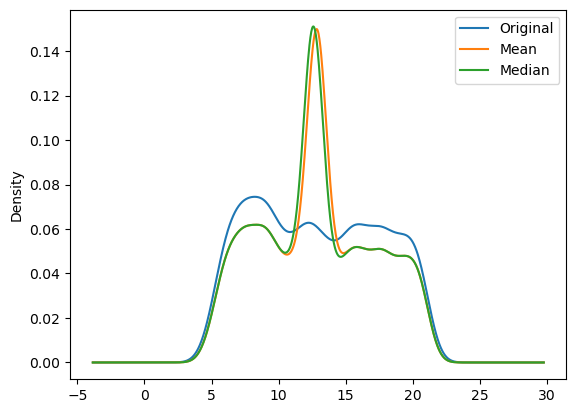

In [23]:
data['Item_Weight'].plot(kind="kde",label="Original")
data['Item_Weight_mean'].plot(kind="kde",label="Mean")
data['Item_Weight_median'].plot(kind="kde",label="Median")
plt.legend()
plt.show()

<Axes: >

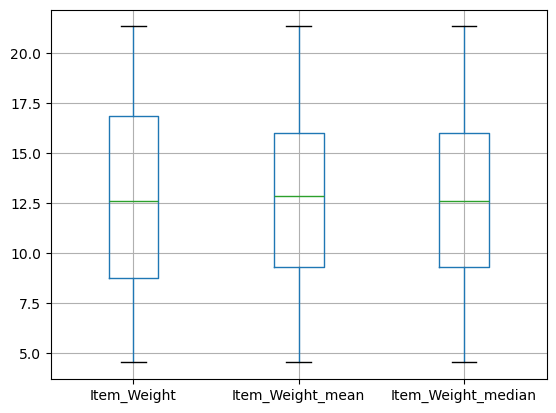

In [24]:
data[['Item_Weight','Item_Weight_mean','Item_Weight_median']].boxplot()

In [25]:
data['Item_Weight_interpolate']=data['Item_Weight'].interpolate(method="linear")

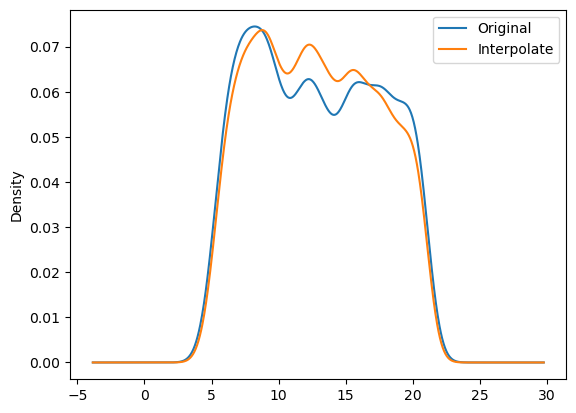

In [26]:
data['Item_Weight'].plot(kind="kde",label="Original")
data['Item_Weight_interpolate'].plot(kind="kde",label="Interpolate")
plt.legend()
plt.show()

In [27]:
from sklearn.impute import KNNImputer

In [28]:
knn=KNNImputer(n_neighbors=10,weights="distance")

In [29]:
data['knn_imputer']=knn.fit_transform(data[['Item_Weight']]).ravel()

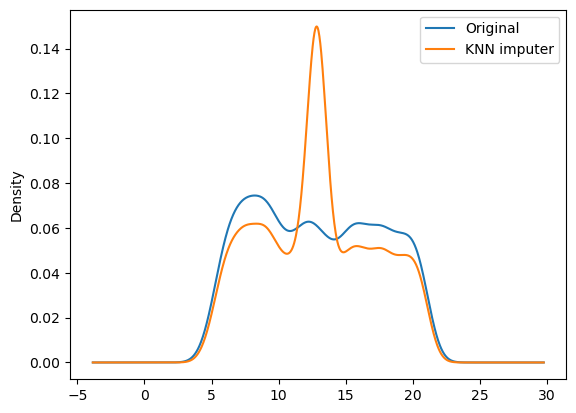

In [30]:
data['Item_Weight'].plot(kind="kde",label="Original")
data['knn_imputer'].plot(kind="kde",label="KNN imputer")
plt.legend()
plt.show()

In [31]:
data=data.drop(['Item_Weight','Item_Weight_mean','Item_Weight_median','knn_imputer'],axis=1)

In [32]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interpolate
0,FDA15,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3


In [33]:
data.isnull().sum()

Item_Identifier                 0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
Item_Weight_interpolate         0
dtype: int64

In [34]:
data['Outlet_Size']

0       Medium
1       Medium
2       Medium
3          NaN
4         High
         ...  
8518      High
8519       NaN
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: object

In [35]:
data['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [36]:
data['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

In [37]:
mode_outlet=data.pivot_table(values='Outlet_Size',columns='Outlet_Type',aggfunc=(lambda x:x.mode()[0]))

In [38]:
mode_outlet

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [39]:
missing_values=data['Outlet_Size'].isnull()

In [40]:
missing_values

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [41]:
data.loc[missing_values,'Outlet_Size']=data.loc[missing_values,'Outlet_Type'].apply(lambda x:mode_outlet[x])

In [42]:
data.isnull().sum()

Item_Identifier              0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Item_Weight_interpolate      0
dtype: int64

In [43]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Item_Weight_interpolate'],
      dtype='object')

In [44]:
data['Item_Fat_Content']

0       Low Fat
1       Regular
2       Low Fat
3       Regular
4       Low Fat
         ...   
8518    Low Fat
8519    Regular
8520    Low Fat
8521    Regular
8522    Low Fat
Name: Item_Fat_Content, Length: 8523, dtype: object

In [45]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [46]:
data.replace({'Item_Fat_Content':{'Low Fat':'LF','low fat':'LF','reg':'Regular'}},inplace=True)

In [47]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
LF         5517
Regular    3006
Name: count, dtype: int64

In [48]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Item_Weight_interpolate'],
      dtype='object')

In [49]:
data['Item_Visibility']

0       0.016047
1       0.019278
2       0.016760
3       0.000000
4       0.000000
          ...   
8518    0.056783
8519    0.046982
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 8523, dtype: float64

In [50]:
data['Item_Visibility'].value_counts()

Item_Visibility
0.000000    526
0.076975      3
0.162462      2
0.076841      2
0.073562      2
           ... 
0.013957      1
0.110460      1
0.124646      1
0.054142      1
0.044878      1
Name: count, Length: 7880, dtype: int64

In [51]:
data['Item_Visibility_interpolate']=data['Item_Visibility'].replace(0,np.nan).interpolate(method='linear')

In [52]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interpolate,Item_Visibility_interpolate
0,FDA15,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047


In [53]:
data['Item_Visibility'].value_counts()

Item_Visibility
0.000000    526
0.076975      3
0.162462      2
0.076841      2
0.073562      2
           ... 
0.013957      1
0.110460      1
0.124646      1
0.054142      1
0.044878      1
Name: count, Length: 7880, dtype: int64

In [54]:
data['Item_Visibility_interpolate'].value_counts()

Item_Visibility_interpolate
0.076975    3
0.044024    2
0.040912    2
0.076856    2
0.078759    2
           ..
0.021011    1
0.099189    1
0.076866    1
0.014116    1
0.044878    1
Name: count, Length: 8405, dtype: int64

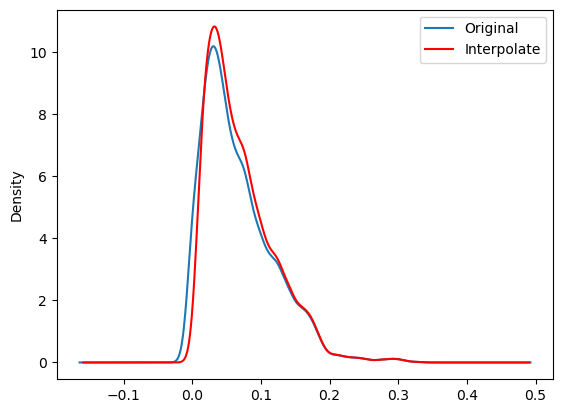

In [55]:
data['Item_Visibility'].plot(kind="kde",label="Original")
data['Item_Visibility_interpolate'].plot(kind="kde",color='red',label="Interpolate")
plt.legend()
plt.show()

In [56]:
data=data.drop('Item_Visibility',axis=1)

In [57]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interpolate', 'Item_Visibility_interpolate'],
      dtype='object')

In [58]:
data['Item_Type']


0                       Dairy
1                 Soft Drinks
2                        Meat
3       Fruits and Vegetables
4                   Household
                ...          
8518              Snack Foods
8519             Baking Goods
8520       Health and Hygiene
8521              Snack Foods
8522              Soft Drinks
Name: Item_Type, Length: 8523, dtype: object

In [59]:
data['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [60]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interpolate', 'Item_Visibility_interpolate'],
      dtype='object')

In [61]:
data['Item_Identifier']

0       FDA15
1       DRC01
2       FDN15
3       FDX07
4       NCD19
        ...  
8518    FDF22
8519    FDS36
8520    NCJ29
8521    FDN46
8522    DRG01
Name: Item_Identifier, Length: 8523, dtype: object

In [62]:
data['Item_Identifier'].value_counts()

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64

In [63]:
data['Item_Identifier'].value_counts().sample(5)

Item_Identifier
FDG40    4
FDC52    4
FDI22    8
NCJ54    5
DRJ35    3
Name: count, dtype: int64

In [64]:
data['Item_Identifier']=data['Item_Identifier'].apply(lambda x:x[:2])

In [65]:
data['Item_Identifier'].value_counts()

Item_Identifier
FD    6125
NC    1599
DR     799
Name: count, dtype: int64

In [66]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interpolate', 'Item_Visibility_interpolate'],
      dtype='object')

In [67]:
data['Outlet_Establishment_Year']

0       1999
1       2009
2       1999
3       1998
4       1987
        ... 
8518    1987
8519    2002
8520    2004
8521    2009
8522    1997
Name: Outlet_Establishment_Year, Length: 8523, dtype: int64

In [68]:
import datetime as dt

In [69]:
current_year=dt.datetime.today().year

In [70]:
current_year

2026

In [71]:
data['Outlet_age']= current_year - data['Outlet_Establishment_Year']

In [72]:
data['Outlet_age']

0       27
1       17
2       27
3       28
4       39
        ..
8518    39
8519    24
8520    22
8521    17
8522    29
Name: Outlet_age, Length: 8523, dtype: int64

In [73]:
data=data.drop('Outlet_Establishment_Year',axis=1)

In [74]:
data

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interpolate,Item_Visibility_interpolate,Outlet_age
0,FD,LF,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,9.300,0.016047,27
1,DR,Regular,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,5.920,0.019278,17
2,FD,LF,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,17.500,0.016760,27
3,FD,Regular,Fruits and Vegetables,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,19.200,0.015755,28
4,NC,LF,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,8.930,0.014751,39
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FD,LF,Snack Foods,214.5218,OUT013,High,Tier 3,Supermarket Type1,2778.3834,6.865,0.056783,39
8519,FD,Regular,Baking Goods,108.1570,OUT045,Small,Tier 2,Supermarket Type1,549.2850,8.380,0.046982,24
8520,NC,LF,Health and Hygiene,85.1224,OUT035,Small,Tier 2,Supermarket Type1,1193.1136,10.600,0.035186,22
8521,FD,Regular,Snack Foods,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,1845.5976,7.210,0.145221,17


In [75]:
from sklearn.preprocessing import OrdinalEncoder
data_encoded=data.copy()
cat_cols=data.select_dtypes(include=["object"]).columns
                                     
for col in cat_cols:
                oe=OrdinalEncoder()
                data_encoded[col]=oe.fit_transform(data_encoded[[col]]) 
                print(oe.categories_)

[array(['DR', 'FD', 'NC'], dtype=object)]
[array(['LF', 'Regular'], dtype=object)]
[array(['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods'], dtype=object)]
[array(['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027',
       'OUT035', 'OUT045', 'OUT046', 'OUT049'], dtype=object)]
[array(['High', 'Medium', 'Small'], dtype=object)]
[array(['Tier 1', 'Tier 2', 'Tier 3'], dtype=object)]
[array(['Grocery Store', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'], dtype=object)]


In [76]:
data_encoded.head(3)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interpolate,Item_Visibility_interpolate,Outlet_age
0,1.0,0.0,4.0,249.8092,9.0,1.0,0.0,1.0,3735.1380,9.30,0.016047,27
1,0.0,1.0,14.0,48.2692,3.0,1.0,2.0,2.0,443.4228,5.92,0.019278,17
2,1.0,0.0,10.0,141.6180,9.0,1.0,0.0,1.0,2097.2700,17.50,0.016760,27


In [77]:
x=data_encoded.drop('Item_Outlet_Sales',axis=1)
y=data_encoded['Item_Outlet_Sales']

In [78]:
x

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Weight_interpolate,Item_Visibility_interpolate,Outlet_age
0,1.0,0.0,4.0,249.8092,9.0,1.0,0.0,1.0,9.300,0.016047,27
1,0.0,1.0,14.0,48.2692,3.0,1.0,2.0,2.0,5.920,0.019278,17
2,1.0,0.0,10.0,141.6180,9.0,1.0,0.0,1.0,17.500,0.016760,27
3,1.0,1.0,6.0,182.0950,0.0,2.0,2.0,0.0,19.200,0.015755,28
4,2.0,0.0,9.0,53.8614,1.0,0.0,2.0,1.0,8.930,0.014751,39
...,...,...,...,...,...,...,...,...,...,...,...
8518,1.0,0.0,13.0,214.5218,1.0,0.0,2.0,1.0,6.865,0.056783,39
8519,1.0,1.0,0.0,108.1570,7.0,2.0,1.0,1.0,8.380,0.046982,24
8520,2.0,0.0,8.0,85.1224,6.0,2.0,1.0,1.0,10.600,0.035186,22
8521,1.0,1.0,13.0,103.1332,3.0,1.0,2.0,2.0,7.210,0.145221,17


In [79]:
y

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64

In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rf=RandomForestRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(rf,x,y,cv=5,scoring='r2')
print(scores.mean())

0.5549938762817801


In [81]:
from xgboost import XGBRFRegressor
xg=XGBRFRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(rf,x,y,cv=5,scoring='r2')
print(scores.mean())

0.5549938762817801


In [82]:
xg=XGBRFRegressor(n_estimators=100,random_state=42)
xg1=xg.fit(x,y)
pd.DataFrame({
    'feature':x.columns,
    'XGBRF_importance':xg1.feature_importances_

}).sort_values(by='XGBRF_importance',ascending=False)

,feature,XGBRF_importance
7,Outlet_Type,0.425649
3,Item_MRP,0.156796
10,Outlet_age,0.156179
4,Outlet_Identifier,0.124377
5,Outlet_Size,0.116917
6,Outlet_Location_Type,0.010875
9,Item_Visibility_interpolate,0.002980
8,Item_Weight_interpolate,0.002385
2,Item_Type,0.002089
1,Item_Fat_Content,0.000980


In [83]:
['Item_Visibility_interpolate','Item_Weight_interpolate','Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content']

['Item_Visibility_interpolate',
 'Item_Weight_interpolate',
 'Item_Type',
 'Outlet_Location_Type',
 'Item_Identifier',
 'Item_Fat_Content']

In [84]:
from xgboost import XGBRFRegressor
xg=XGBRFRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(xg1,x.drop(['Item_Visibility_interpolate','Item_Weight_interpolate','Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content'],axis=1),y,cv=5,scoring='r2')
print(scores.mean())

0.5963725820550024


In [85]:
final_data=x.drop(columns=['Item_Visibility_interpolate','Item_Weight_interpolate','Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content'],axis=1)

In [86]:
final_data

,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Type,Outlet_age
0,249.8092,9.0,1.0,1.0,27
1,48.2692,3.0,1.0,2.0,17
2,141.6180,9.0,1.0,1.0,27
3,182.0950,0.0,2.0,0.0,28
4,53.8614,1.0,0.0,1.0,39
...,...,...,...,...,...
8518,214.5218,1.0,0.0,1.0,39
8519,108.1570,7.0,2.0,1.0,24
8520,85.1224,6.0,2.0,1.0,22
8521,103.1332,3.0,1.0,2.0,17


In [87]:
from xgboost import XGBRFRegressor

In [88]:
xg_final=XGBRFRegressor()

In [89]:
xg_final.fit(final_data, y)

,learning_rate,1.0
,subsample,0.8
,colsample_bynode,0.8
,reg_lambda,1e-05
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bytree,None
,device,None


In [90]:
y_pred=xg_final.predict(final_data)
print(y_pred[:5])


[4036.1917   716.4022  2036.1234   472.31006  834.06323]


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [92]:
X_train,X_text,y_train,y_test = train_test_split(final_data,y,test_size=0.20,random_state=42)

In [93]:
xg_final.fit(X_train,y_train)

,learning_rate,1.0
,subsample,0.8
,colsample_bynode,0.8
,reg_lambda,1e-05
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bytree,None
,device,None


In [94]:
y_pred = xg_final.predict(X_text)

In [95]:
mean_absolute_error(y_test,y_pred)

712.8038386091287

In [96]:
pred = xg_final.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2054.5735


In [97]:
pred = xg_final.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2054.5735


In [98]:
import joblib

In [99]:
joblib.dump(xg_final,'bigmart_model')

['bigmart_model']

In [100]:
model = joblib.load('bigmart_model')

In [101]:
predict = model.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2054.5735


In [102]:
print(f"Sales Values is between {pred-712.80} and {pred+712.80}")

Sales Values is between 1341.7734375 and 2767.37353515625


In [3]:
import numpy as np
import datetime as dt
from tkinter import *
import joblib
current_year = dt.datetime.today().year
def show_entry_fields():
    p1=float(e1.get())
    #p4=float(e4.get())
    
    text = clicked.get()
    if text == "OUT010":
        p2=0
        print(p2)
    elif text=="OUT013":
        p2=1
        print(p2)
    elif text=="OUT017":
        p2=2
        print(p2)
    elif text=="OUT018":
        p2=3
        print(p2)
    elif text=="OUT019":
        p2=4
        print(p2)
    elif text=="OUT027":
        p2=5
        print(p2)
    elif text=="OUT035":
        p2=6
        print(p2)
    elif text=="OUT045":
        p2=7
        print(p2)
    elif text=="OUT046":
        p2=8
        print(p2)
    elif text=="OUT049":
        p2=9
        print(p2)
    text0 = clicked0.get()
    if text0 == "High":
        p3=0
        print(p3)
    elif text0=="Medium":
        p3=1
        print(p3)
    elif text0=="Small":
        p3=2
        print(p3)
        
    text1 = clicked1.get()
    if text1 == "Supermarket Type1":
        p4=1
        print(p4)
    elif text1=="Supermarket Type2":
        p4=2
        print(p4)
    elif text1=="Supermarket Type3":
        p4=3
        print(p4)
    elif text1=="Grocery Store":
        p4=0
        print(p4)
    
    p5=current_year - int(e5.get())
    print(p5)
    
    model = joblib.load('bigmart_model')
    result=model.predict(np.array([[p1,p2,p3,p4,p5]]))
    Label(master, text="Sales Amount is in between").grid(row=8)
    Label(master, text=float(result) -714.42 ).grid(row=10)
    Label(master, text="and").grid(row=11)
    Label(master, text=float(result) + 714.42) .grid(row=12)
    print("Sales amount", result)
    
master = Tk()
master.title("Big Mart Sales Prediction using Machine Learning")


label = Label(master, text = " Big Mart Sales Prediction using ML"
                          , bg = "black", fg = "white"). \
                               grid(row=0,columnspan=2)

# Item_MRP	Outlet_Identifier	Outlet_Size	Outlet_Type	Outlet_age
Label(master, text="Item_MRP").grid(row=1)
Label(master, text="Outlet_Identifier").grid(row=2)
Label(master, text="Outlet_Size").grid(row=3)
Label(master, text="Outlet_Type").grid(row=4)
Label(master, text="Outlet_Establishment_Year").grid(row=5)


clicked = StringVar()
options = ['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027',
       'OUT035', 'OUT045', 'OUT046', 'OUT049']

clicked0 = StringVar()

options0 = ['High', 'Medium', 'Small']

clicked1 = StringVar()
options1 = ['Grocery Store', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3']

e1 = Entry(master)

e2 = OptionMenu(master , clicked , *options )
e2.configure(width=15)


e3 = OptionMenu(master , clicked0 , *options0 )
e3.configure(width=15)


e4 = OptionMenu(master , clicked1 , *options1 )
e4.configure(width=15)

e5 = Entry(master)


e1.grid(row=1, column=1)
e2.grid(row=2, column=1)
e3.grid(row=3, column=1)
e4.grid(row=4, column=1)
e5.grid(row=5, column=1)



Button(master, text='Predict', command=show_entry_fields).grid()

mainloop()

5
1
1
23
Sales amount [4107.597]


C:\Users\boomi\AppData\Local\Temp\ipykernel_12608\3442783360.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Label(master, text=float(result) -714.42 ).grid(row=10)
C:\Users\boomi\AppData\Local\Temp\ipykernel_12608\3442783360.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Label(master, text=float(result) + 714.42) .grid(row=12)


Current Sales Calculation: 248.0998


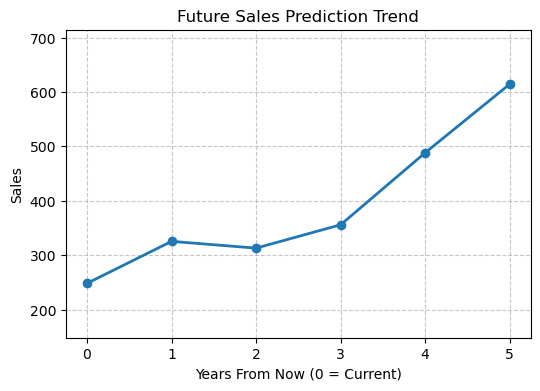

In [ ]:
import datetime as dt
from tkinter import *
import joblib
import matplotlib.pyplot as plt
import numpy as np

current_year = dt.datetime.today().year

master = Tk()
master.title("Big Mart Sales Prediction using Machine Learning")

# UI Layout Components
label = Label(
    master, text=" Big Mart Sales Prediction using ML", bg="black", fg="white"
).grid(row=0, columnspan=2)

Label(master, text="Item_MRP").grid(row=1)
Label(master, text="Outlet_Identifier").grid(row=2)
Label(master, text="Outlet_Size").grid(row=3)
Label(master, text="Outlet_Type").grid(row=4)
Label(master, text="Outlet_Establishment_Year").grid(row=5)

clicked = StringVar()
options = [
    "OUT010",
    "OUT013",
    "OUT017",
    "OUT018",
    "OUT019",
    "OUT027",
    "OUT035",
    "OUT045",
    "OUT046",
    "OUT049",
]

clicked0 = StringVar()
options0 = ["High", "Medium", "Small"]

clicked1 = StringVar()
options1 = [
    "Grocery Store",
    "Supermarket Type1",
    "Supermarket Type2",
    "Supermarket Type3",
]

e1 = Entry(master)
e2 = OptionMenu(master, clicked, *options)
e2.configure(width=15)
e3 = OptionMenu(master, clicked0, *options0)
e3.configure(width=15)
e4 = OptionMenu(master, clicked1, *options1)
e4.configure(width=15)
e5 = Entry(master)

e1.grid(row=1, column=1)
e2.grid(row=2, column=1)
e3.grid(row=3, column=1)
e4.grid(row=4, column=1)
e5.grid(row=5, column=1)


def show_entry_fields():
    # 1. Parse Inputs from GUI
    p1 = float(e1.get())

    text = clicked.get()
    if text == "OUT010":
        p2 = 0
    elif text == "OUT013":
        p2 = 1
    elif text == "OUT017":
        p2 = 2
    elif text == "OUT018":
        p2 = 3
    elif text == "OUT019":
        p2 = 4
    elif text == "OUT027":
        p2 = 5
    elif text == "OUT035":
        p2 = 6
    elif text == "OUT045":
        p2 = 7
    elif text == "OUT046":
        p2 = 8
    elif text == "OUT049":
        p2 = 9

    text0 = clicked0.get()
    if text0 == "High":
        p3 = 0
    elif text0 == "Medium":
        p3 = 1
    elif text0 == "Small":
        p3 = 2

    text1 = clicked1.get()
    if text1 == "Supermarket Type1":
        p4 = 1
    elif text1 == "Supermarket Type2":
        p4 = 2
    elif text1 == "Supermarket Type3":
        p4 = 3
    elif text1 == "Grocery Store":
        p4 = 0

    p5 = current_year - int(e5.get())

    # 2. Load ML Model
    model = joblib.load("bigmart_model")

    # 3. Calculate Current and Future Trends
    years = list(range(0, 6))  # Starts at 0 so Year 0 = Current Sales
    future_preds = []

    for i in years:
        future_mrp = p1 + (i * 20)  # At i=0, MRP is unchanged
        future_age = p5 + i  # At i=0, Age is unchanged

        pred = model.predict(
            np.array([[future_mrp, p2, p3, p4, future_age]])
        )[0]
        future_preds.append(pred)

    current_pred = future_preds[0]  # First element is exactly today's sales

    # 4. Generate Plot Output
    plt.figure(figsize=(6, 4))
    plt.plot(years, future_preds, marker="o", color="#1f77b4", linewidth=2)
    plt.title("Future Sales Prediction Trend")
    plt.xlabel("Years From Now (0 = Current)")
    plt.ylabel("Sales")
    plt.ylim(bottom=min(future_preds) - 100, top=max(future_preds) + 100)
    plt.grid(True, linestyle="--", alpha=0.7)

    # 5. Update Tkinter Window Interface
    Label(master, text="Predicted Sales:").grid(row=8, column=0)
    Label(master, text=f"{current_pred:.2f}").grid(row=8, column=1)

    print("Current Sales Calculation:", current_pred)
    plt.show()


Button(master, text="Predict", command=show_entry_fields).grid(
    row=6, columnspan=2, pady=10
)

mainloop()